In [1]:
#NLP---natural language processing
#nltk----naltural language toolkit----library used in python for nlp

In [2]:
#6 steps--preprocessing steps using nltk
#1--lower()---(kind, Kind)
#2---re()---remove all the special characters, punctuations
#3---tokenization---converting sentence to words
#4---stop word removal---(ex--is, the, that, are, were)
#5---stemming or lemmatization
#----stemming---(convert to root word--ex--playing -> play,it may create words which is not in dictionary)
#-----lemmatization----(convert to root word--ex--playing -> play, uses proper dictionary format)
#6----vectorization-----converting to numeric values

In [3]:
# "This Product is AMAZING!!! Totally worth it "

# lowercase → "this product is amazing!!! totally worth it"
# remove special → this product is amazing totally worth it
# tokenize → ["this","product","is","amazing","totally","worth","it"]
# remove stopwords → ["product","amazing","worth"]
# lemmatize → ["product","amazing","worth"]
# vectorize → numerical vector

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#Load the dataset
df=pd.read_csv("C:\\Users\\rrbra\\Downloads\\fake reviews dataset.csv")
df

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...
...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ..."
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...


In [6]:
#Data inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


In [7]:
df.describe()

,rating
count,40432.000000
mean,4.256579
std,1.144354
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [8]:
#Check for null values
print(df.isnull().sum())

category    0
rating      0
label       0
text_       0
dtype: int64


In [9]:
#Check for value counts
a=['category','rating','label']
for i in a:
    print("Column : ",i)
    print(df[i].value_counts())
    print("------------------------------")

Column :  category
Kindle_Store_5                  4730
Books_5                         4370
Pet_Supplies_5                  4254
Home_and_Kitchen_5              4056
Electronics_5                   3988
Sports_and_Outdoors_5           3946
Tools_and_Home_Improvement_5    3858
Clothing_Shoes_and_Jewelry_5    3848
Toys_and_Games_5                3794
Movies_and_TV_5                 3588
Name: category, dtype: int64
------------------------------
Column :  rating
5.0    24559
4.0     7965
3.0     3786
1.0     2155
2.0     1967
Name: rating, dtype: int64
------------------------------
Column :  label
CG    20216
OR    20216
Name: label, dtype: int64
------------------------------


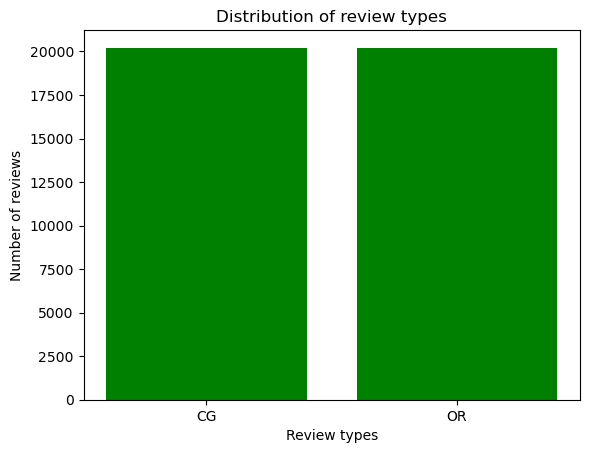

In [10]:
#Visualizations
#Distribution of review types

x=df['label'].value_counts()
m=x.index
n=x.values
plt.bar(m,n,color='g')
plt.title('Distribution of review types')
plt.xlabel('Review types')
plt.ylabel('Number of reviews')
plt.show()

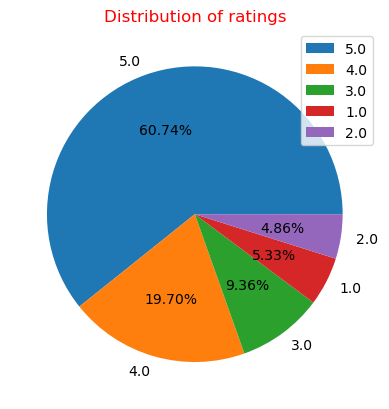

In [11]:
#Distribution of ratings
k=df['rating'].value_counts()
a=k.index
b=k.values
plt.pie(b,labels=a,autopct='%1.2f%%')
plt.title("Distribution of ratings",color='red')
plt.legend(a)
plt.show()

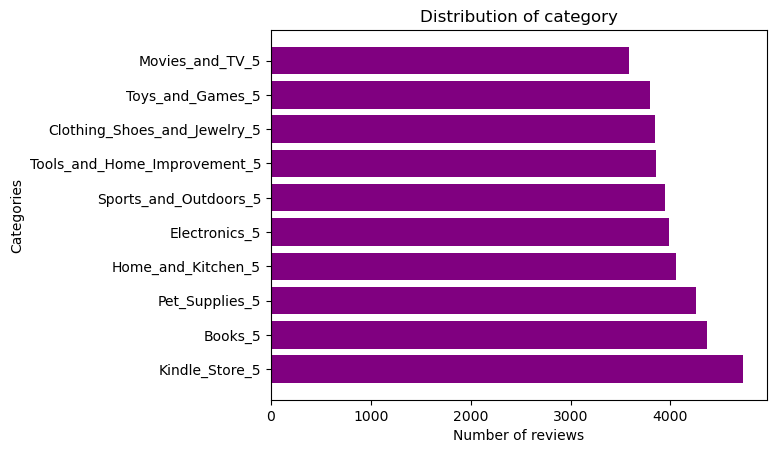

In [12]:
#Visualizations
#Distribution of category

x=df['category'].value_counts()
m=x.index
n=x.values
plt.barh(m,n,color='purple')
plt.title('Distribution of category')
plt.xlabel('Number of reviews')
plt.ylabel('Categories')
plt.show()

In [13]:
#Encoding--label column

# Convert label column: CG → 1 (Fake), OR → 0 (Original)
df['label'] = df['label'].map({'CG': 1, 'OR': 0})

# Check if conversion worked
df['label'].value_counts()

1    20216
0    20216
Name: label, dtype: int64

In [14]:
#Rename column 
df=df.rename(columns={'text_':"text"}) 
df.columns

Index(['category', 'rating', 'label', 'text'], dtype='object')

In [15]:
#Nlp steps for text column

# Step 1: Lowercase all review text
df['text_lower'] = df['text'].astype(str).str.lower()
df[['text', 'text_lower']].head()

,text,text_lower
0,"Love this! Well made, sturdy, and very comfor...","love this! well made, sturdy, and very comfor..."
1,"love it, a great upgrade from the original. I...","love it, a great upgrade from the original. i..."
2,This pillow saved my back. I love the look and...,this pillow saved my back. i love the look and...
3,"Missing information on how to use it, but it i...","missing information on how to use it, but it i..."
4,Very nice set. Good quality. We have had the s...,very nice set. good quality. we have had the s...


In [16]:
import re
import string

# Step 2: Remove punctuation and special characters
def remove_punctuation(text):
    return re.sub(f"[{re.escape(string.punctuation)}]", "", text)

df['text_no_punct'] = df['text_lower'].apply(remove_punctuation)
df[['text_lower', 'text_no_punct']].head()


,text_lower,text_no_punct
0,"love this! well made, sturdy, and very comfor...",love this well made sturdy and very comfortab...
1,"love it, a great upgrade from the original. i...",love it a great upgrade from the original ive...
2,this pillow saved my back. i love the look and...,this pillow saved my back i love the look and ...
3,"missing information on how to use it, but it i...",missing information on how to use it but it is...
4,very nice set. good quality. we have had the s...,very nice set good quality we have had the set...


In [17]:
#step 3
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

# Step 3: Tokenize the cleaned text
df['tokens'] = df['text_no_punct'].apply(word_tokenize)
df[['text_no_punct', 'tokens']].head()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rrbra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rrbra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,text_no_punct,tokens
0,love this well made sturdy and very comfortab...,"[love, this, well, made, sturdy, and, very, co..."
1,love it a great upgrade from the original ive...,"[love, it, a, great, upgrade, from, the, origi..."
2,this pillow saved my back i love the look and ...,"[this, pillow, saved, my, back, i, love, the, ..."
3,missing information on how to use it but it is...,"[missing, information, on, how, to, use, it, b..."
4,very nice set good quality we have had the set...,"[very, nice, set, good, quality, we, have, had..."


In [18]:
#step 4
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
#print(stop_words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rrbra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
# Step 4: Remove stopwords from token list
df['tokens_no_stopwords'] = df['tokens'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
df[['tokens', 'tokens_no_stopwords']].head()

,tokens,tokens_no_stopwords
0,"[love, this, well, made, sturdy, and, very, co...","[love, well, made, sturdy, comfortable, love, ..."
1,"[love, it, a, great, upgrade, from, the, origi...","[love, great, upgrade, original, ive, mine, co..."
2,"[this, pillow, saved, my, back, i, love, the, ...","[pillow, saved, back, love, look, feel, pillow]"
3,"[missing, information, on, how, to, use, it, b...","[missing, information, use, great, product, pr..."
4,"[very, nice, set, good, quality, we, have, had...","[nice, set, good, quality, set, two, months]"


In [20]:
#step 5: Lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

# Step 5: Lemmatize each token
df['lemmatized_tokens'] = df['tokens_no_stopwords'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])
df[['tokens_no_stopwords', 'lemmatized_tokens']].head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rrbra\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\rrbra\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,tokens_no_stopwords,lemmatized_tokens
0,"[love, well, made, sturdy, comfortable, love, ...","[love, well, made, sturdy, comfortable, love, ..."
1,"[love, great, upgrade, original, ive, mine, co...","[love, great, upgrade, original, ive, mine, co..."
2,"[pillow, saved, back, love, look, feel, pillow]","[pillow, saved, back, love, look, feel, pillow]"
3,"[missing, information, use, great, product, pr...","[missing, information, use, great, product, pr..."
4,"[nice, set, good, quality, set, two, months]","[nice, set, good, quality, set, two, month]"


In [22]:
# Step 6: Join tokens back into a cleaned string
df['final_cleaned_text'] = df['lemmatized_tokens'].apply(lambda tokens: " ".join(tokens))
df[['text', 'final_cleaned_text']].head()

,text,final_cleaned_text
0,"Love this! Well made, sturdy, and very comfor...",love well made sturdy comfortable love itvery ...
1,"love it, a great upgrade from the original. I...",love great upgrade original ive mine couple year
2,This pillow saved my back. I love the look and...,pillow saved back love look feel pillow
3,"Missing information on how to use it, but it i...",missing information use great product price
4,Very nice set. Good quality. We have had the s...,nice set good quality set two month


In [23]:
#step 7: vectorization and labeling (Word2vector,TFIDFVectorizer)
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer object
vectorizer = TfidfVectorizer(max_features=5000)  # you can adjust features

# Fit and transform the cleaned text
x = vectorizer.fit_transform(df['final_cleaned_text'])

# Target label
y = df['label']

In [24]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [25]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(32345, 5000)
(8087, 5000)
(32345,)
(8087,)


In [26]:
#Model selection or model building

# 1.import algorithm
from sklearn.linear_model import LogisticRegression
# 2.object for class
# model 
lr=LogisticRegression()

In [27]:
#Model training
lr.fit(x_train,y_train)

LogisticRegression()

In [28]:
#Model testing---x_text data
result=lr.predict(x_test)
print(result)

[1 1 0 ... 1 0 0]


In [29]:
#model evaluation

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score=accuracy_score(y_test,result)
print("Accuracy Score for LR Model:",score)

Accuracy Score for LR Model: 0.8717695066155559


In [30]:
#classification report
report=classification_report(y_test,result)
print("Classification Report :\n")
print(report)

Classification Report :

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      4071
           1       0.88      0.85      0.87      4016

    accuracy                           0.87      8087
   macro avg       0.87      0.87      0.87      8087
weighted avg       0.87      0.87      0.87      8087



[[3620  451]
 [ 586 3430]]


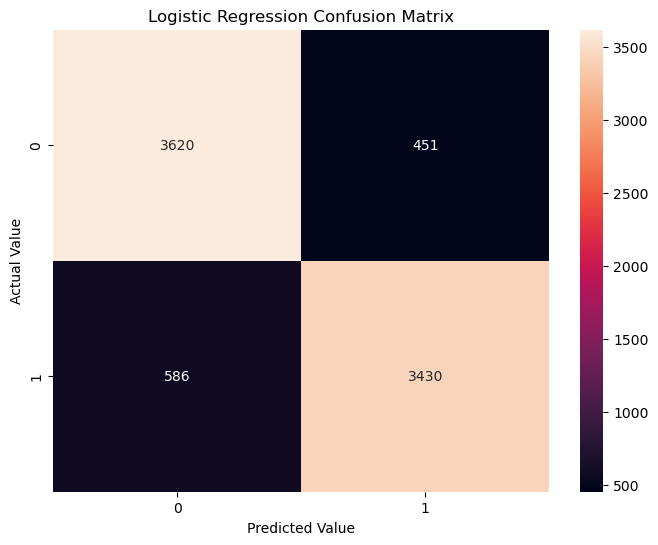

In [31]:
#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,result)
print(cm)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Logistic Regression Confusion Matrix")

sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [32]:
# Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier
# model building
dt=DecisionTreeClassifier()
#Model training
dt.fit(x_train,y_train)

#Model testing---x_text data

result_dt=dt.predict(x_test)
print(result_dt)

[1 1 1 ... 0 0 0]


Accuracy Score for DT Model: 0.7488561889452208
Classification Report :

              precision    recall  f1-score   support

           0       0.75      0.74      0.75      4071
           1       0.74      0.76      0.75      4016

    accuracy                           0.75      8087
   macro avg       0.75      0.75      0.75      8087
weighted avg       0.75      0.75      0.75      8087

[[3023 1048]
 [ 983 3033]]


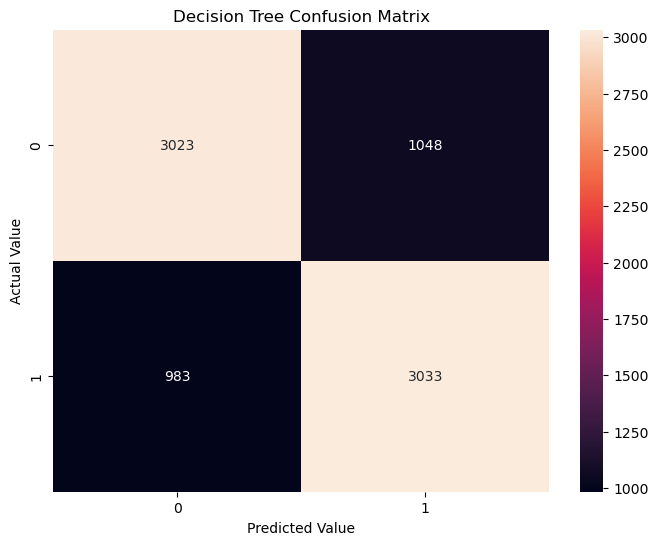

In [33]:
#model evaluation

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score_dt=accuracy_score(y_test,result_dt)
print("Accuracy Score for DT Model:",score_dt)

#classification report
report_dt=classification_report(y_test,result_dt)
print("Classification Report :\n")
print(report_dt)

#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt=confusion_matrix(y_test,result_dt)
print(cm_dt)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Decision Tree Confusion Matrix")

sns.heatmap(cm_dt,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [34]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

# model building
rf=RandomForestClassifier()
#Model training
rf.fit(x_train,y_train)
#Model testing---x_text data
result_rf=rf.predict(x_test)
print(result_rf)

[1 1 0 ... 1 0 0]


Accuracy Score for RF Model: 0.8509954247557809
Classification Report :

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4071
           1       0.83      0.87      0.85      4016

    accuracy                           0.85      8087
   macro avg       0.85      0.85      0.85      8087
weighted avg       0.85      0.85      0.85      8087

[[3370  701]
 [ 504 3512]]


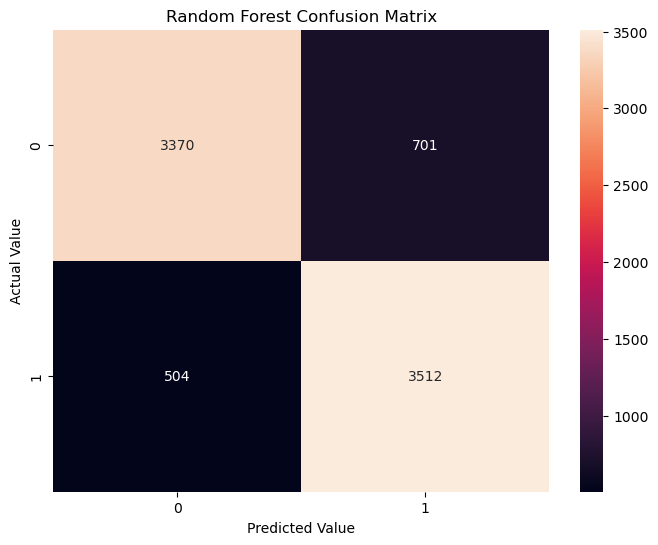

In [35]:
#model evaluation

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score_rf=accuracy_score(y_test,result_rf)
print("Accuracy Score for RF Model:",score_rf)

#classification report
report_rf=classification_report(y_test,result_rf)
print("Classification Report :\n")
print(report_rf)

#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf=confusion_matrix(y_test,result_rf)
print(cm_rf)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Random Forest Confusion Matrix")

sns.heatmap(cm_rf,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [36]:
#Support Vector machine
from sklearn.svm import SVC
# model building
svc=SVC()
#Model training
svc.fit(x_train,y_train)
#Model testing---x_text data
result_svc=svc.predict(x_test)
print(result_svc)

[1 1 0 ... 1 0 0]


Accuracy Score for RF Model: 0.8883393100037097
Classification Report :

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      4071
           1       0.91      0.87      0.89      4016

    accuracy                           0.89      8087
   macro avg       0.89      0.89      0.89      8087
weighted avg       0.89      0.89      0.89      8087

[[3706  365]
 [ 538 3478]]


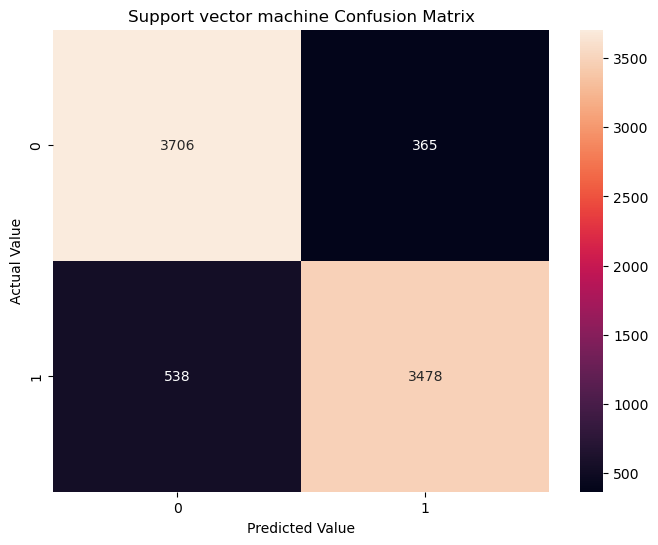

In [37]:
#model evaluation

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score_svc=accuracy_score(y_test,result_svc)
print("Accuracy Score for RF Model:",score_svc)

#classification report
report_svc=classification_report(y_test,result_svc)
print("Classification Report :\n")
print(report_svc)

#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svc=confusion_matrix(y_test,result_svc)
print(cm_svc)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Support vector machine Confusion Matrix")

sns.heatmap(cm_svc,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [38]:
import joblib

# Save SVM model
joblib.dump(svc, 'svm_model_nlp.pkl')

# Save TF-IDF vectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [40]:
import joblib
import re
import string
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download (only first time)
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

# Load saved model and vectorizer
svm_model = joblib.load('svm_model_nlp.pkl')
tfidf_vectorizer = joblib.load('tfidf_vectorizer.pkl')

def predict_fake_review_svm(text):
    
    # Step 1: Lowercase
    text = text.lower()
    
    # Step 2: Remove punctuation
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    
    # Step 3: Tokenization
    tokens = word_tokenize(text)
    
    # Step 4: Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # Step 5: Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Step 6: Join tokens
    clean_text = " ".join(tokens)
    
    # Step 7: Vectorize
    X_input = tfidf_vectorizer.transform([clean_text])
    
    # Step 8: Predict
    prediction = svm_model.predict(X_input)[0]
    print(prediction)
    
    return "Original Review" if prediction == 0 else "Computer Generated Review"

In [41]:
text = "I love pyrex quality and this set is the best. I will be purchasing more in the future"

print("SVM Prediction:", predict_fake_review_svm(text))

1
SVM Prediction: Computer Generated Review
